# Uvozi

In [64]:
import math
from IPython.display import display, Latex
from fractions import Fraction
import numpy as np
import matplotlib.pyplot as plt
from IPython import embed

# Nazivni podaci

In [65]:
m = 3                          #Broj faza #TODO
P_2 = 5000                     #Nazivna mehanicka snaga (W) #TODO
U = 60                         #Napon DC medjukruga (V) #TODO
n = 1500                       #Brzina vrtnje rotora (rpm) #TODO
f = 50                         #Frekvencija (Hz) #TODO
p = 3                          #Broj pari polova #TODO
T_ok = 40                      #Temperatura okoline (stupnjevi Celzij) #TODO
T_n = 120                      #Temperatura namota i magneta (stupnjevi Celzij) #TODO

# Glavne dimenzije

In [66]:
B_delta1 = 1.1                #Amplituda prvog harmonika magnetske indukcije u zr. rasporu (T) #TODO
A_srms = 30000                #Strujni oblog statora (A/m) #TODO

M_n = round((5000*30)/(1500*math.pi),2)  #Nazivni moment (Nm)
display(Latex(rf'$M_{{n}} =  {M_n}\,\mathrm{{Nm}}$'))

eta = 0.915        #Korisnost motora #TODO
eta_delta = round(eta/(0.25+0.75*eta),2)  #Korisnost motora u zr rasporu
display(Latex(rf'$\eta_{{\delta}} =  {eta_delta}$'))

tau_p = 0.06       #Polni korak (m) #TODO
display(Latex(rf'$\tau_{{p}} =  {tau_p}\,\mathrm{{m}}$'))

cos_phi_delta = 0.92   #Faktor snage u zr rasporu #TODO
display(Latex(rf'$\cos({{\varphi_{{\delta}}}}) =  {cos_phi_delta}$'))

D = round(tau_p*(2*p)/(math.pi),2)   #Promjer provrta statora (m)
display(Latex(rf'$D =  {D}\,\mathrm{{m}}$'))

l = round((P_2)/((math.pi**2)/(math.sqrt(2)*p)*B_delta1*A_srms*f*eta_delta*cos_phi_delta*D**2),2)   #Duljina paketa statora (m)
display(Latex(rf'$l =  {l}\,\mathrm{{m}}$'))

D_v = round(D*1.85,2)                      #Promjer vanjskog dijela statora (m) #TODO
display(Latex(rf'$D_{{v}} =  {D_v}\,\mathrm{{m}}$'))

D_os = 0.038                           #Promjer osovine (m) #TODO
display(Latex(rf'$D_{{os}} =  {D_os}\,\mathrm{{m}}$'))

#delta = round((0.2+0.03*math.sqrt((D*l*10**6)/2)),3)   #Duljina zr raspora (mm)
delta = 1.1                             #Duljina zr raspora (mm) #TODO
display(Latex(rf'$\delta =  {delta}\,\mathrm{{mm}}$'))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

# Određivanje radne točke permanentnog magneta

In [67]:
B_r = 1.11            #Remanencija magneta na temperaturi od 120 stupnjeva (T)  #TODO
H_c = 835000          #Koercitivnost magneta na temperaturi od 120 stupnjeva (A/m)  #TODO
mi_0 = 4*math.pi*10**(-7)     #Magnetska permeabilnost zraka (H/m)

mi_r = round(B_r/(H_c*mi_0),2)     #Relativna permeabilnost magneta na 120 stupnjeva

display(Latex(rf'$\mu =  {mi_r}$'))

k_c = 1.02              #Carterov faktor za zracni raspor  #TODO
k_sat = 1.2             #Faktor koji u obzir uzima zasicenje  #TODO
delta_ideal = round(delta * k_c * k_sat,2)    #Idealni zracni raspor (mm)
display(Latex(rf"$\delta'  =  {delta_ideal}\,\mathrm{{mm}}$"))

alpha_m = 130           #Kutna sirina magneta (stupnjevi elektricni) #TODO

B_delta_m1 = round(B_delta1*cos_phi_delta,2)    #Osnovni harmonik magnetske indukcije magneta u zr rasporu (T)
display(Latex(rf'$B_{{\delta \mathrm{{m1}}}} =  {B_delta_m1}\,\mathrm{{T}}$'))

B_delta_m = round((math.pi*B_delta_m1)/(4*math.sin(math.radians(alpha_m/2))),2)     #Max vrijednost indukcije koju proizvode magneti u zr rasporu - idealna (T)
display(Latex(rf'$B_{{\delta \mathrm{{m}}}} =  {B_delta_m}\,\mathrm{{T}}$'))

h_m = round((delta_ideal*mi_r)/((B_r)/(B_delta_m) - 1),2)       #Debljina magneta (mm)
display(Latex(rf'$h_{{m}} =  {h_m}\,\mathrm{{mm}}$'))

H_m = round(-(B_delta_m*delta_ideal)/(mi_0*h_m),0)     #Jakost magnetskog pola za manget - radna tocka magneta (A/m)
display(Latex(rf'$H_{{m}} =  {H_m}\,\mathrm{{\frac{{A}}{{m}}}}$'))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

# Kombinacija utora i polova

In [68]:
Q_s = 27                     #Broj utora statora #TODO
y = 3                        #Korak svitka #TODO

q = Q_s/(2*p*m)              #Broj utora po polu i fazi
q_frac = Fraction(q)

display(Latex(rf'$q =  {q_frac}$'))

a_q = q_frac.numerator       #Prividni broj utora po polu i fazi
b_q = q_frac.denominator     #Prividni broj polova

tau_p_slots = Q_s/(2*p)      #Polni korak po broju utora
display(Latex(rf'$\tau_{{p}} =  {tau_p_slots}$'))

t = math.gcd(Q_s,p)          #Najveci zajednicki visektratnik izmedju broja utora i pari polova - toliko se puta ponavlja magnetska slika
display(Latex(rf'$t =  {t}$'))

Q_t = round(Q_s/t)                  #Broj fazora napona u zvijezdi napona
display(Latex(rf'$Q_{{t}} =  {Q_t}$'))

alpha = (p*360)/Q_s          #Elektricni kut izmedju dvaju utora (stupnjevi)
display(Latex(rf'$\alpha =  {alpha}\degree$'))

alpha_virtual = 180/(m*a_q)  #Prividni elektricjni kut izmedju dvaju utora (stupnjevi)
display(Latex(rf"$\alpha' =  {alpha_virtual}\degree$"))

f_z = round((math.sin(math.radians(a_q*alpha_virtual/2)))/(a_q*math.sin(math.radians(alpha_virtual/2))),3)  #Zonski faktor namota
display(Latex(rf'$f_{{z}} =  {f_z}$'))

f_t = round(math.sin((y*math.pi)/(tau_p_slots*2)),3)   #Tetivni faktor namota
display(Latex(rf'$f_{{t}} =  {f_t}$'))

f_n = round(f_z*f_t,3)           #Ukupan faktor namota za prvi harmonik
display(Latex(rf'$f_{{n}} =  {f_n}$'))

C_t = round((2*p*Q_s)/math.lcm(Q_s,2*p))    #Faktor dobrote za "moment zupčanika"
display(Latex(rf'$C_{{t}} =  {C_t}$'))

p_sile = round((2*p)/b_q)            #Broj pari polova za radijalne sile
display(Latex(rf"$p' =  {p_sile}$"))


 



<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

# Dizajn statorskog utora i namota

In [69]:
f_ispune = 0.4                           #Faktor ispune utora bakrom

phi_m = (D*l*B_delta_m1)/p               #Tok u zracnom rasporu proizveden od magneta (Wb)
display(Latex(rf'$\Phi_{{m}} =  {phi_m*10**3}\,\mathrm{{mWb}}$'))

U_f = U/(math.sqrt(2)*math.sqrt(3))      #RMS vrijednost faznog napona sa pretpostavkom da je stroj spojen u zvijezdu (V)

E = round((0.98*U_f*cos_phi_delta),2)   #Inducirani napon u stroju po fazi (V)
display(Latex(rf'$E =  {E}\,\mathrm{{V}}$'))

z = round(E/(2.22*phi_m*f_n*f))           #Broj vodica spojen u seriju
display(Latex(rf'$z =  {z}$'))

a = 1                                     #Broj paralelnih grana
z_ut = round((z*m*a)/Q_s)                 #Broj vodica u utoru
display(Latex(rf'$z_{{ut}} =  {z_ut}$'))

if z_ut % 2 == 0:                         #Dio koda koji odreduje jesu li potrebne paralelne grane ili ne, ne ide se na vise od a = 2
    z_ut_isp = z_ut
else:
    a = 2
    z_ut_isp = z_ut*a

test = (2*p)/(a*b_q)

if test.is_integer():                             #Dio koda koji provjerava je li ispunjen uvjet za paralelne grane kod razlomljenog namota
    print("Broj paralelnih grana je u redu !")
else:
    print("Broj paralelnih grana NIJE u redu !")
     
display(Latex(rf'$z_{{utIsp}} =  {z_ut_isp}$'))
display(Latex(rf'$a =  {a}$'))

# Sada se sa poznatim brojem vodica u utoru racunaju ispravljene vrijednosti prijasnjih velicina:

z_isp = round((z_ut_isp*Q_s)/(m*a))          #Ispravljeni broj vodica spojenih u seriju
display(Latex(rf'$z_{{isp}} =  {z_isp}$'))

phi_m_isp = (E)/(2.22*z_isp*f*f_n)            #Ispravljeni magnetski tok (Wb)
display(Latex(rf'$\Phi_{{m}} =  {phi_m_isp}\,\mathrm{{Wb}}$'))

B_delta_m1_isp = round((phi_m_isp*p)/(D*l),2)                  #Ispravljeni prvi harmonik magnetske indukcije magneta (T)
display(Latex(rf'$B_{{\delta \mathrm{{m1Isp}}}} =  {B_delta_m1_isp}\,\mathrm{{T}}$'))

B_delta_m_isp = round((math.pi*B_delta_m1_isp)/(4*math.sin(math.radians(alpha_m/2))),2)    #Ispravljena max vrijednost indukcije koju proizvode magneti u zr rasporu - idealna (T)
display(Latex(rf'$B_{{\delta \mathrm{{mIsp}}}} =  {B_delta_m_isp}\,\mathrm{{T}}$'))

h_m_isp = round((delta_ideal*mi_r)/((B_r)/(B_delta_m_isp) - 1),2)            #Ispravljena debljina magneta (mm)
display(Latex(rf'$h_{{mIsp}} =  {h_m_isp}\,\mathrm{{mm}}$'))

cos_phi = 0.93               #Pretpostavljeni faktor snage stroja (za 1% veci od onoga u zraku) #TODO

I = round((P_2)/(3*U_f*eta*cos_phi),2)  #RMS vrijednost fazne struje (A)
display(Latex(rf'$I_{{rms}} =  {I}\,\mathrm{{A}}$'))
 
J = 5                        #Odabrana gustoca struje u stroju (A/mm2) #TODO
q_vod = round((I)/(a*J))            #Poprecni presjek jednog vodica (mm2)
display(Latex(rf'$q_{{vod}} =  {q_vod}\,\mathrm{{mm^{{2}}}}$'))

S_cu = q_vod*z_ut_isp        #Povrsina bakra u vodicu (mm2)
display(Latex(rf'$S_{{cu}} =  {S_cu}\,\mathrm{{mm^{{2}}}}$'))

S_ut = S_cu/f_ispune         #Povrsina utora (mm2)
display(Latex(rf'$S_{{ut}} =  {S_ut}\,\mathrm{{mm^{{2}}}}$'))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Broj paralelnih grana je u redu !


...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

# Određivanje dimenzija statorskog utora - skripta prof. Žarka

In [70]:
# INPUT DATA
# All input and output dimensions are in meters

bo = 3.5e-3    # Slot opening width
ho = 0.64e-3   # Slot opening height
rc2 = 1.2e-3   # Curvature radius at the bottom of the slot
D = D     # Stator bore diameter
Qs = Q_s        # Number of stator slots
bt = 7e-3    # Tooth width
hs = 27.3e-3   # Total slot height

# -------------------------------------------------------------
Rs = D / 2
alphao = 2 * math.asin(0.5 * bo / Rs)   # slot opening in rad
thetas = 2 * math.pi / Qs

x1 = bo / 2
y1 = Rs * math.cos(alphao * 0.5)
x2 = x1
y2 = y1 + ho

deltar = bt / (2 * math.sin(thetas * 0.5))
a1 = math.cos(thetas * 0.5) ** 2
b1 = 2 * (deltar * math.sin(thetas * 0.5) ** 2 - Rs * math.cos(alphao * 0.5) - ho)
c1 = (bo ** 2) * 0.25 + (Rs * math.cos(alphao * 0.5) + ho) ** 2 - deltar ** 2 * math.sin(thetas * 0.5) ** 2

q1 = (-b1 + math.sqrt(b1 ** 2 - 4 * a1 * c1)) / (2 * a1)
rc1 = math.sqrt(x2 ** 2 + (q1 - y2) ** 2)

x3 = 0.5 * math.sin(thetas) * (q1 - deltar)
y3 = -x3 * math.tan(thetas * 0.5) + q1

bs = 2 * (Rs + hs) * math.tan(thetas * 0.5) - bt / math.cos(thetas * 0.5)  # slot width
gama = math.atan(2 * (Rs - deltar + hs) / bs)

p2 = bs * 0.5 - rc2 / math.tan(gama * 0.5)
q2 = Rs + hs

y4 = (q2 + p2 * math.tan(thetas * 0.5) + deltar * math.tan(thetas * 0.5) ** 2) / \
     (1 + math.tan(thetas * 0.5) ** 2)

x4 = (q2 - y4) / math.tan(thetas * 0.5) + p2

x5 = bs * 0.5 - rc2 / math.tan(gama * 0.5)
y5 = Rs + hs

alpha1 = math.atan(x3 / (q1 - y3))
alpha2 = math.atan(x2 / (q1 - y2))
alpha3 = math.atan((bs * 0.5 - x5) / rc2)

S11 = (rc1 ** 2) * alpha1 - 0.5 * rc1 ** 2 * math.sin(2 * alpha1) \
    - (rc1 ** 2) * alpha2 + 0.5 * rc1 ** 2 * math.sin(2 * alpha2)

S21 = -rc2 * (bs * 0.5 - x5) + rc2 ** 2 * alpha3

A = 2 * (y4 - y3) / (x4 - x3)
B = y3 - y5 + (-x3 + 0.5 * bs) * (y4 - y3) / (x4 - x3)
C = (-S21 + S11 - 0.5 * bs * y5 - x3 * y3
     + (x3 + 0.5 * bs) * (y3 - (y4 - y3) / (x4 - x3) * x3))

x6 = (-B + math.sqrt(B ** 2 - 4 * A * C)) / (2 * A)
y6 = y3 + (y4 - y3) / (x4 - x3) * (x6 - x3)

# -------------------------------------------------------------
# OUTPUT DATA
# Slot dimensions

h1 = y3 - y2
h2 = y6 - y3
h3 = y5 - y6

b1 = 2 * x3
b2 = 2 * x6
# bs already defined

# Area of the top half of the slot (mm^2)
S1 = (S11 + (x3 + x6) * (y6 - y3)) * 1e6

# Area of the bottom half of the slot (mm^2)
S2 = (S21 + 0.5 * (bs + 2 * x6) * (y5 - y6)) * 1e6

# Total slot area
Sslot = S1 + S2

display(Latex(rf'$h_{{1}} =  {h1*10**3}\,\mathrm{{mm^{{2}}}}$'))
display(Latex(rf'$h_{{2}} =  {h2*10**3}\,\mathrm{{mm^{{2}}}}$'))
display(Latex(rf'$h_{{3}} =  {h3*10**3}\,\mathrm{{mm^{{2}}}}$'))
display(Latex(rf'$b_{{1}} =  {b1*10**3}\,\mathrm{{mm^{{2}}}}$'))
display(Latex(rf'$b_{{2}} =  {b2*10**3}\,\mathrm{{mm^{{2}}}}$'))
display(Latex(rf'$b_{{utora}} =  {bs*10**3}\,\mathrm{{mm^{{2}}}}$'))

display(Latex(rf'$S_{{utora}} =  {Sslot}\,\mathrm{{mm^{{2}}}}$'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

# Dizajn magnetskog kruga

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

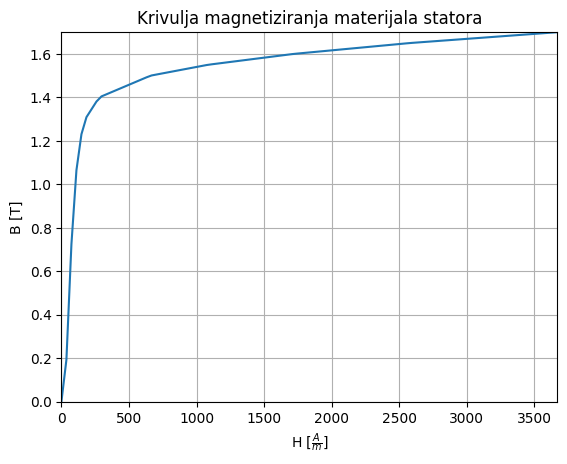

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

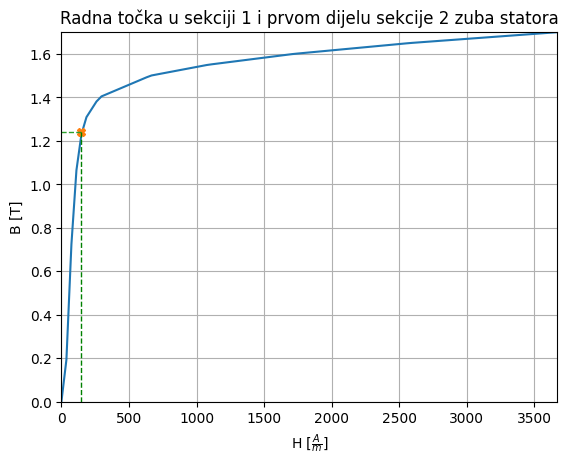

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

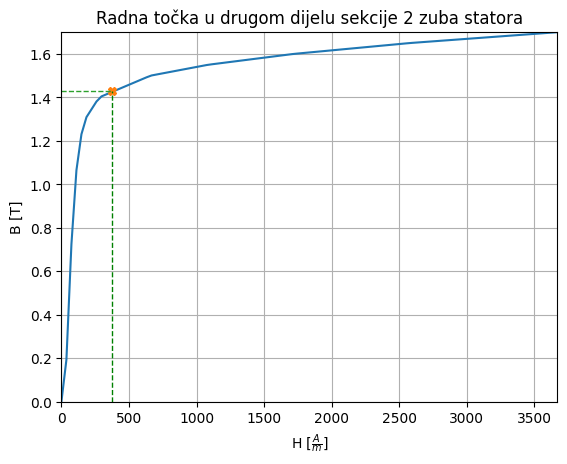

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

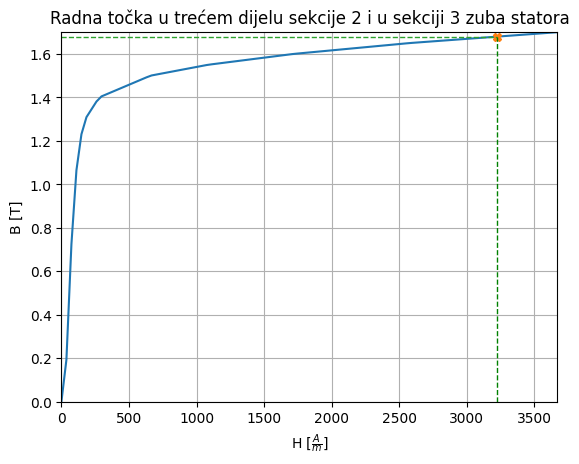

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

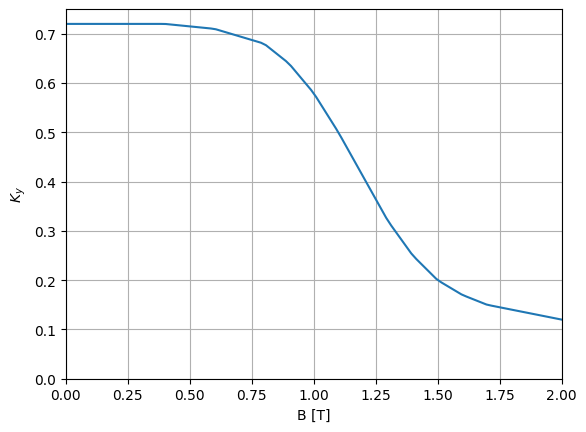

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

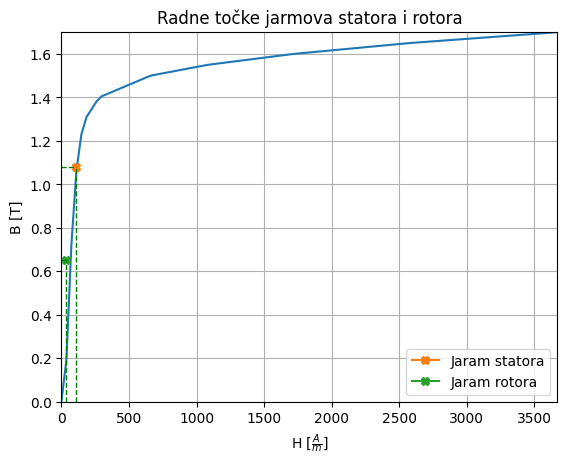

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Broj iteracija:  2


In [71]:
k_fe = 0.97            #Faktor ispunjenja statora zeljezom #TODO

##Pad magnetskog napona u zracnome rasporu

tau_s = round((D*math.pi)/Q_s,3)      #Utorski korak (m)
display(Latex(rf'$\tau_{{s}} =  {tau_s}\,\mathrm{{m}}$'))

delta_kc = delta + h_m/mi_r           #Zracni raspor za racun Carterovog faktora
display(Latex(rf'$\delta_{{kc}} =  {delta_kc}\,\mathrm{{mm^{{2}}}}$'))

k_c = round(tau_s/(tau_s-(2*bo/math.pi)*(math.atan(bo/2*delta_kc)-(delta_kc/bo)*math.log(1+(bo/(2*delta_kc))**2))),3)    #Carterov faktor
display(Latex(rf'$k_{{c}} =  {k_c}$'))

V_delta = round(k_c * delta * 10**-3 *(B_delta_m)/mi_0,2)        #Pad magnetskog napona u zr rasporu (A)
display(Latex(rf'$V_{{\delta}} =  {V_delta}\,\mathrm{{A}}$'))

B_T = np.array([
    0.0,0.10, 0.20, 0.40, 0.70, 1.00,
    1.20, 1.30, 1.40, 1.50, 1.55,
    1.60, 1.65, 1.70
])                                             #Polje vrijednosti magnetske indukcije na 50 Hz #TODO

H_50Hz = np.array([
    0.0,26.5, 37.8, 52.4, 71.9, 99.3,
    136.0, 176.0, 279.0, 659.0, 1084.0,
    1718.0, 2577.0, 3670.0
])                                            #Polje vrijednosti jakosti magnetskog polja na 50 Hz #TODO

H_interp = np.linspace(0.0,3670.0,100)        #Kod za crtanje krivulje magnetiziranja - linearna interpolacija   #TODO
B_interp = np.interp(H_interp,H_50Hz,B_T)     

plt.plot(H_interp, B_interp)                  #Crtanje

plt.xlim([0.0,max(H_interp)])                 #Granice x i y osi
plt.ylim([0.0,max(B_interp)])
plt.xlabel(r"H [$\frac{A}{m}]$")              #Oznake na x i y osima
plt.ylabel("B [T]")
plt.grid()                                    #Ukljuci mrezu
plt.title("Krivulja magnetiziranja materijala statora")
plt.show()                                    #Pokazi graf

#Proracun za sekciju 1 zuba

b_t1 = tau_s - bo            #Sirina zuba (m)
display(Latex(rf'$b_{{t1}} =  {b_t1*10**3}\,\mathrm{{mm}}$'))
B_t1_priv = round((B_delta_m_isp*tau_s)/(k_fe*b_t1),2)           #Prividna magnetska indukcija u zubu (T)
display(Latex(rf"$B_{{t1}}' =  {B_t1_priv}\,\mathrm{{T}}$"))

if (B_t1_priv >= 1.8):                                           #Ako je zasicenje
    plt.figure()
    k_t1 = tau_s/(k_fe*b_t1) - 1                                 #Pomocni faktor za izracun povrsine zuba
    plt.plot(H_interp,B_interp, label = 'Krivulja magnetiziranja' ) #Crtanje krivulje magnetiziranja
    B_t1 = B_t1_priv - H_interp*k_t1*mi_0                        #Pravac stvarne magnetske indukcije u zubu
    plt.plot(H_interp,B_t1, label = 'Indukcija u zubu')          #Crtanje pravca indukcije u zubu
    res = np.where(np.sign(B_t1-B_interp)[:-1] != np.sign(B_t1-B_interp)[1:])[0]         #Trazenje precsjecista dviju krivulja

    B_pres = round(B_t1[res[0]],2)                                 #Spremanje presjecista
    H_pres = round(H_interp[res[0]],2)

    display(Latex(rf"$B_{{t1}}' =  {B_pres}\,\mathrm{{T}}$"))                 
    display(Latex(rf'$H_{{t1}} =  {H_pres}\,\mathrm{{\frac{{A}}{{m}}}}$'))

    plt.xlabel(r"H [$\frac{A}{m}]$")                            #Postavljanje labela na osi
    plt.ylabel("B [T]")

    plt.legend()                                  #Legenda
    plt.grid()                                    #Mreza
    plt.title("Radna točka u sekciji 1 i prvom dijelu sekcije 2 zuba statora")
    plt.show()                                    

    B_t1_res = B_pres                             #Spremanje rezultata
    H_t1_res = H_pres

else:
    B_t1_res = B_t1_priv                          #Mag indukcija u zubu jednaka prividnoj
    res = np.where(np.sign(B_t1_res-B_interp[:-1]) != np.sign(B_t1_res-B_interp[1:]))[0]       #Trazenje H na krivulji magnetiziranja
    H_t1_res = round(H_interp[res[0]],2)                  #Spremanje rezultata

    plt.plot(H_interp, B_interp)                  #Crtanje

    plt.xlim([0.0,max(H_interp)])                 #Granice x i y osi
    plt.ylim([0.0,max(B_interp)])
    plt.xlabel(r"H [$\frac{A}{m}]$")              #Oznake na x i y osima
    plt.ylabel("B [T]")
    plt.grid()                                    #Ukljuci mrezu

    plt.plot(H_t1_res,B_t1_res, marker = "X")
    plt.plot([0,H_t1_res],[B_t1_res,B_t1_res],linestyle = "dashed",linewidth = "1")
    plt.plot([H_t1_res,H_t1_res], [0, B_t1_res], linestyle = "dashed",linewidth = "1", color = "green")
    display(Latex(rf"$B_{{t1}} =  {B_t1_res}\,\mathrm{{T}}$"))
    display(Latex(rf'$H_{{t1}} =  {H_t1_res}\,\mathrm{{\frac{{A}}{{m}}}}$'))
    plt.title("Radna točka u sekciji 1 i prvom dijelu sekcije 2 zuba statora")
    plt.show()

V_t1 = round(H_t1_res * ho,4) #Pad magnetskog napona u sekciji 1
display(Latex(rf'$V_{{t1}} =  {V_t1}\,\mathrm{{A}}$'))

#Proracun za sekciju 2 zuba

#Prvi dio sekcije 2 (y0 = 0)

B_t2_dio1_res = B_t1_res
H_t2_dio1_res = H_t1_res

display(Latex(rf"$B_{{t2y0}} =  {B_t2_dio1_res}\,\mathrm{{T}}$"))
display(Latex(rf'$H_{{t2y0}} =  {H_t2_dio1_res}\,\mathrm{{\frac{{A}}{{m}}}}$'))

#Drugi dio sekcije 2 (y1 = h1/2)

b_t2_dio2 = (b_t1+bt)/2             #Aproksimativna sirina zuba na sekciji 2 (m)
display(Latex(rf"$b_{{t2y1}} =  {b_t2_dio2*10**3}\,\mathrm{{mm}}$"))
B_t2_dio2_priv = round((B_delta_m*tau_s)/(k_fe*b_t2_dio2),2)    #Prividna magnetska indukcija u sekciji 2 zuba (T)
display(Latex(rf"$B_{{t2y1}}' =  {B_t2_dio2_priv}\,\mathrm{{T}}$"))

if (B_t2_dio2_priv >= 1.8):                                           #Ako je zasicenje
    plt.figure()
    k_t2 = tau_s/(k_fe*b_t2_dio2) - 1                                 #Pomocni faktor za izracun povrsine zuba
    plt.plot(H_interp,B_interp, label = 'Krivulja magnetiziranja' ) #Crtanje krivulje magnetiziranja
    B_t2_dio2 = B_t2_dio2_priv - H_interp*k_t2*mi_0                        #Pravac stvarne magnetske indukcije u zubu
    plt.plot(H_interp,B_t2_dio2, label = 'Indukcija u zubu')          #Crtanje pravca indukcije u zubu
    res = np.where(np.sign(B_t2_dio2-B_interp)[:-1] != np.sign(B_t2_dio2-B_interp)[1:])[0]         #Trazenje precsjecista dviju krivulja

    B_pres = round(B_t2_dio2[res[0]],2)                                 #Spremanje presjecista
    H_pres = round(H_interp[res[0]],2)

    display(Latex(rf"$B_{{t1}}' =  {B_pres}\,\mathrm{{T}}$"))                 
    display(Latex(rf'$H_{{t1}} =  {H_pres}\,\mathrm{{\frac{{A}}{{m}}}}$'))

    plt.xlabel(r"H [$\frac{A}{m}]$")                            #Postavljanje labela na osi
    plt.ylabel("B [T]")

    plt.legend()                                  #Legenda
    plt.grid()                                    #Mreza
    plt.title("Radna točka u drugom dijelu sekcije 2 zuba statora")
    plt.show()                                    

    B_t2_dio2_res = B_pres                             #Spremanje rezultata
    H_t2_dio2_res = H_pres

else:
    B_t2_dio2_res = B_t2_dio2_priv                          #Mag indukcija u zubu jednaka prividnoj
    res = np.where(np.sign(B_t2_dio2_res-B_interp[:-1]) != np.sign(B_t2_dio2_res-B_interp[1:]))[0]       #Trazenje H na krivulji magnetiziranja
    H_t2_dio2_res = round(H_interp[res[0]],2)                  #Spremanje rezultata
    
    plt.plot(H_interp, B_interp)                  #Crtanje

    plt.xlim([0.0,max(H_interp)])                 #Granice x i y osi
    plt.ylim([0.0,max(B_interp)])
    plt.xlabel(r"H [$\frac{A}{m}]$")              #Oznake na x i y osima
    plt.ylabel("B [T]")
    plt.grid()                                    #Ukljuci mrezu

    plt.plot(H_t2_dio2_res,B_t2_dio2_res, marker = "X")
    plt.plot([0,H_t2_dio2_res],[B_t2_dio2_res,B_t2_dio2_res],linestyle = "dashed",linewidth = "1")
    plt.plot([H_t2_dio2_res,H_t2_dio2_res], [0, B_t2_dio2_res], linestyle = "dashed",linewidth = "1", color = "green")

    plt.title("Radna točka u drugom dijelu sekcije 2 zuba statora")
    plt.show()
    display(Latex(rf"$B_{{t2y1}} =  {B_t2_dio2_res}\,\mathrm{{T}}$"))
    display(Latex(rf'$H_{{t2y1}} =  {H_t2_dio2_res}\,\mathrm{{\frac{{A}}{{m}}}}$'))

#Treci dio sekcije 2 (y1 = h1)

b_t2_dio3 = bt           #Sirina zuba na sekciji 3 (m)
display(Latex(rf'$b_{{t3}} =  {b_t2_dio3*10**3}\,\mathrm{{mm}}$'))

B_t2_dio3_priv = round((B_delta_m*tau_s)/(k_fe*b_t2_dio3),2)     #Prividna indukcija na sekciji 3 (T)
display(Latex(rf"$B_{{t3}}' =  {B_t2_dio3_priv}\,\mathrm{{T}}$"))

if (B_t2_dio3_priv >= 1.8):                                           #Ako je zasicenje
    plt.figure()
    k_t3 = tau_s/(k_fe*b_t2_dio3) - 1                                 #Pomocni faktor za izracun povrsine zuba
    plt.plot(H_interp,B_interp, label = 'Krivulja magnetiziranja' ) #Crtanje krivulje magnetiziranja
    B_t2_dio3 = B_t2_dio3_priv - H_interp*k_t3*mi_0                        #Pravac stvarne magnetske indukcije u zubu
    plt.plot(H_interp,B_t2_dio3, label = 'Indukcija u zubu')          #Crtanje pravca indukcije u zubu
    res = np.where(np.sign(B_t2_dio3-B_interp)[:-1] != np.sign(B_t2_dio3-B_interp)[1:])[0]         #Trazenje precsjecista dviju krivulja

    B_pres = round(B_t2_dio3[res[0]],2)                                 #Spremanje presjecista
    H_pres = round(H_interp[res[0]],2)

    display(Latex(rf"$B_{{t1}}' =  {B_pres}\,\mathrm{{T}}$"))                 
    display(Latex(rf'$H_{{t1}} =  {H_pres}\,\mathrm{{\frac{{A}}{{m}}}}$'))

    plt.xlabel(r"H [$\frac{A}{m}]$")                            #Postavljanje labela na osi
    plt.ylabel("B [T]")

    plt.legend()                                  #Legenda
    plt.grid()                                    #Mreza
    plt.title("Radna točka u trećem dijelu sekcije 2 i u sekciji 3 zuba statora")
    plt.show()                                    

    B_t2_dio3_res = B_pres                             #Spremanje rezultata
    H_t2_dio3_res = H_pres

else:
    B_t2_dio3_res = B_t2_dio3_priv                          #Mag indukcija u zubu jednaka prividnoj
    res = np.where(np.sign(B_t2_dio3_res-B_interp[:-1]) != np.sign(B_t2_dio3_res-B_interp[1:]))[0]       #Trazenje H na krivulji magnetiziranja
    H_t2_dio3_res = round(H_interp[res[0]],2)                  #Spremanje rezultata
    
    plt.plot(H_interp, B_interp)                  #Crtanje

    plt.xlim([0.0,max(H_interp)])                 #Granice x i y osi
    plt.ylim([0.0,max(B_interp)])
    plt.xlabel(r"H [$\frac{A}{m}]$")              #Oznake na x i y osima
    plt.ylabel("B [T]")
    plt.grid()                                    #Ukljuci mrezu

    plt.plot(H_t2_dio3_res,B_t2_dio3_res, marker = "X")
    plt.plot([0,H_t2_dio3_res],[B_t2_dio3_res,B_t2_dio3_res],linestyle = "dashed",linewidth = "1")
    plt.plot([H_t2_dio3_res,H_t2_dio3_res], [0, B_t2_dio3_res], linestyle = "dashed",linewidth = "1", color = "green")
    plt.title("Radna točka u trećem dijelu sekcije 2 i u sekciji 3 zuba statora")
    plt.show()
    display(Latex(rf"$B_{{t2y1}} =  {B_t2_dio3_res}\,\mathrm{{T}}$"))
    display(Latex(rf'$H_{{t2y1}} =  {H_t2_dio3_res}\,\mathrm{{\frac{{A}}{{m}}}}$'))

V_t2 = round((h1/6) * (H_t2_dio1_res + 4*H_t2_dio2_res + H_t2_dio3_res),2) #Pad magnetskog napona u sekciji 2
display(Latex(rf'$V_{{t2}} =  {V_t2}\,\mathrm{{A}}$'))

#Proracun za sekciju 3 zuba

B_t3_res = B_t2_dio3_res    #Magnetska indukcija u sekciji 3 zuba (T)
H_t3_res = H_t2_dio3_res    #Jakost magnetskog polja u sekciji 3 zuba (A/m)
display(Latex(rf"$B_{{t3}}' =  {B_t3_res}\,\mathrm{{T}}$"))                 
display(Latex(rf'$H_{{t3}} =  {H_t3_res}\,\mathrm{{\frac{{A}}{{m}}}}$'))

V_t3 = round(H_t3_res * (h2+h3),2)  #Pad magnetskog napona u sekciji 3 zuba (A)
display(Latex(rf'$V_{{t3}} =  {V_t3}\,\mathrm{{A}}$'))

V_t_uk = round(V_t1 + V_t2 + V_t3,2)  #Ukupan pad magnetskog napona u zubu statora (A)
display(Latex(rf'$V_{{tuk}} =  {V_t_uk}\,\mathrm{{A}}$'))

#Racun za statorski i rotorski jaram

B_ky = np.array([                                   #Koeficijent Ky na grafu
    0.0, 0.2, 0.4, 0.6, 0.8,
    0.9, 1.0, 1.1, 1.2, 1.3,
    1.4, 1.5, 1.6, 1.7, 1.8,
    1.9, 2.0
])

Ky = np.array([
    0.72, 0.72, 0.72, 0.71, 0.68,
    0.64, 0.58, 0.50, 0.41, 0.32,
    0.25, 0.20, 0.17, 0.15, 0.14,
    0.13, 0.12
])

B_ky_interp = np.linspace(0.0,2.0,100)
Ky_interp = np.interp(B_ky_interp,B_ky,Ky)

plt.plot(B_ky_interp,Ky_interp)
plt.xlabel("B [T]")
plt.ylabel("$K_{y}$")
plt.xlim([0.0,max(B_ky)])
plt.ylim([0.0,0.75])
plt.grid()
plt.show()

h_js = round((D_v-(D+2*hs))/2,4)      #Visina jarma statora (m)
display(Latex(rf'$h_{{js}} =  {h_js*10**3}\,\mathrm{{mm}}$'))

D_r = D-2*(delta+h_m_isp)*10**-3           #Dijametar rotora (m)
display(Latex(rf'$D_{{r}} =  {D_r}\,\mathrm{{m}}$'))

h_jr = round((D_r-D_os)/2,4)                   #Visina jarma rotora (m)
display(Latex(rf'$h_{{jr}} =  {h_jr*10**3}\,\mathrm{{mm}}$'))

B_js = round((phi_m_isp)/(2*k_fe*h_js*l),2)             #Magnetska indukcija u jarmu statora (T)
display(Latex(rf'$B_{{js}} =  {B_js}\,\mathrm{{T}}$'))

B_jr = round((phi_m_isp)/(2*k_fe*h_jr*l),2)              #Magnetska indukcija u jarmu rotora (T)
display(Latex(rf'$B_{{jr}} =  {B_jr}\,\mathrm{{T}}$'))

res = np.where(np.sign(B_js-B_interp[:-1]) != np.sign(B_js-B_interp[1:]))[0]      #Trazenje jakosti magnetskog polja na krivulji magnetiziranja
H_js = round(H_interp[res[0]],2)          #Jakost magnetskog polja u jarmu statora (A/m) 

res = np.where(np.sign(B_js-B_ky_interp[:-1]) != np.sign(B_js-B_ky_interp[1:]))[0]    #Trazenje koeficijenta  
K_js = round(Ky_interp[res[0]],2)         #Koeficijent koji u obzir uzima raspodjelu indukcije u statoru

display(Latex(rf'$H_{{js}} =  {H_js}\,\mathrm{{\frac{{A}}{{m}}}}$'))
display(Latex(rf'$K_{{js}} =  {K_js}$'))


res = np.where(np.sign(B_jr-B_interp[:-1]) != np.sign(B_jr-B_interp[1:]))[0]      #Trazenje jakosti magnetskog polja na krivulji magnetiziranja
H_jr = round(H_interp[res[0]],2)          #Jakost magnetskog polja u jarmu statora (A/m) 

res = np.where(np.sign(B_jr-B_ky_interp[:-1]) != np.sign(B_jr-B_ky_interp[1:]))[0]    #Trazenje koeficijenta 
K_jr = round(Ky_interp[res[0]],2)         #Koeficijent koji u obzir uzima raspodjelu indukcije u rotoru

display(Latex(rf'$H_{{jr}} =  {H_jr}\,\mathrm{{\frac{{A}}{{m}}}}$'))
display(Latex(rf'$K_{{jr}} =  {K_jr}$'))

plt.plot(H_interp, B_interp)                  #Crtanje

plt.xlim([0.0,max(H_interp)])                 #Granice x i y osi
plt.ylim([0.0,max(B_interp)])
plt.xlabel(r"H [$\frac{A}{m}]$")              #Oznake na x i y osima
plt.ylabel("B [T]")
plt.grid()                                    #Ukljuci mrezu

plt.plot(H_js,B_js, marker = "X", label = "Jaram statora")
plt.plot(H_jr,B_jr, marker = "X", label = "Jaram rotora")

plt.plot([0,H_js],[B_js,B_js],linestyle = "dashed",linewidth = "1",color = "green")
plt.plot([H_js,H_js], [0, B_js], linestyle = "dashed",linewidth = "1", color = "green")

plt.plot([0,H_jr],[B_jr,B_jr],linestyle = "dashed",linewidth = "1",color = "green")
plt.plot([H_jr,H_jr], [0, B_jr], linestyle = "dashed",linewidth = "1", color = "green")

plt.legend()
plt.title("Radne točke jarmova statora i rotora")

plt.show()

l_js = round(((D_v-h_js)*math.pi)/(2*p) + 0.6*h_js,2)      #Duljina magnetske silnice u jarmu statora (m)
display(Latex(rf'$l_{{js}} =  {l_js}\,\mathrm{{m}}$'))

V_js = round(H_js*l_js*K_js,2)           #Pad magnetskog napona u jarmu statora (A)
display(Latex(rf'$V_{{js}} =  {V_js}\,\mathrm{{A}}$'))

l_jr = round(((D_os+h_jr)*math.pi)/(2*p)+0.6*h_jr,2)     #Duljina magnetske silnice u jarmu rotora (m)
display(Latex(rf'$l_{{jr}} =  {l_jr}\,\mathrm{{m}}$'))

V_jr = round(H_jr*l_jr*K_jr,2)           #Pad magnetskog napona u jarmu rotora (A)
display(Latex(rf'$V_{{jr}} =  {V_jr}\,\mathrm{{A}}$'))

k_zas = round(1+(V_t_uk + (V_js/2) + (V_jr/2))/(V_delta),4)      #Faktor zasicenja
display(Latex(rf'$k_{{zas}} =  {k_zas}$'))

#Ponovno racunanje h_m,D_r,k_c,V_delta,h_jr,V_jr

h_m_stari = 0
#h_m_novi = round(k_sat*(delta_ideal*mi_r)/((B_r)/(B_delta_m) - 1),2) 
h_m_novi = h_m
iter = 0

while (abs((h_m_stari - h_m_novi)/h_m_novi) > 0.02):
    iter += 1
    h_m_stari = h_m_novi
    k_zas = round(1+(V_t_uk + (V_js/2) + (V_jr/2))/(V_delta),4)
    h_m_novi = round(k_zas*k_c*(delta*mi_r)/((B_r)/(B_delta_m) - 1),2)
    D_r_novi = D - 2*(h_m_novi + delta)*10**-3
    delta_kc_novi = delta + h_m_novi/mi_r
    k_c_novi = round(tau_s/(tau_s-(2*bo/math.pi)*(math.atan(bo/2*delta_kc_novi)-(delta_kc_novi/bo)*math.log(1+(bo/(2*delta_kc_novi))**2))),3)
    V_delta_novi = round(k_c_novi * delta * 10**-3 *(B_delta_m)/mi_0,2)
    h_jr_novi = round((D_r_novi-D_os)/2,4)
    l_jr_novi = round(((D_os+h_jr_novi)*math.pi)/(2*p)+0.6*h_jr_novi,2)
    V_jr_novi = round(H_jr*l_jr_novi*K_jr,2)

    V_jr = V_jr_novi
    V_delta = V_delta_novi
    k_c = k_c_novi
    #display(Latex(rf'$h_{{mnovi}} =  {h_m_novi}$'))
    #display(Latex(rf'$D_{{rnovi}} =  {D_r_novi}$'))

display(Latex(rf'$h_{{mnovi}} =  {h_m_novi}\,\mathrm{{mm}}$'))
print("Broj iteracija: ",iter)

h_m = h_m_novi
D_r = D_r_novi
delta_kc = delta_kc_novi
h_jr = h_jr_novi
l_jr = l_jr_novi



    



# Gubici i korisnost

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

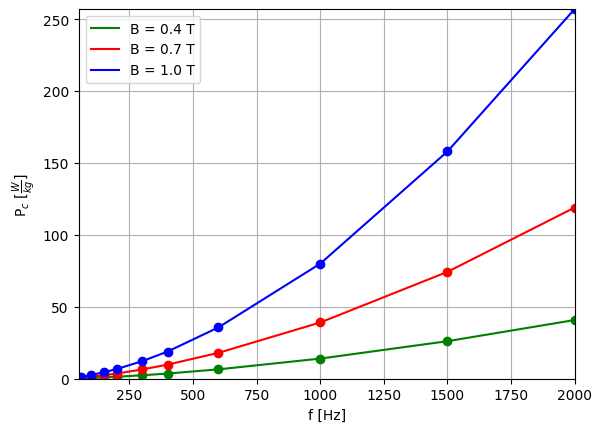

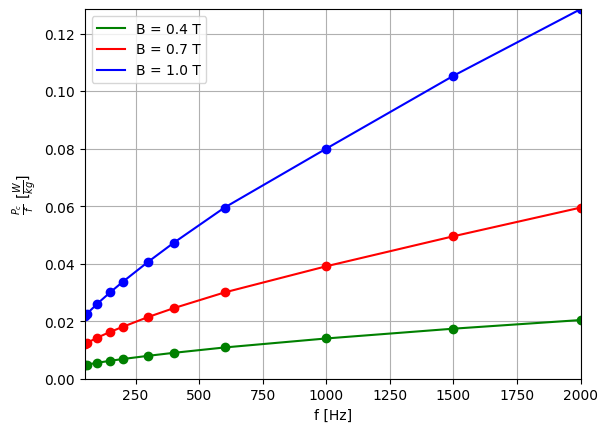

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Red harmonika do kojeg su se kalkulirali gubici:  3


In [ ]:
A = 1.45               #Koeficijent za racunanje duljine glave namota #TODO
B = 30*10**-3          #Koeficijent za racunanje duljine glave namota #TODO

l_gl = round(A*(math.pi*(D+hs)*y)/Q_s + B,4)          #Duljina glave namota (m)
display(Latex(rf'$l_{{gl}} =  {l_gl}\,\mathrm{{m}}$'))

sigma_cu = 38.92                         #Toplinska vodljivost bakra (klasa izolacije F)
R_cu = round((z_ut_isp*Q_s*(l+l_gl))/(sigma_cu*m*a**2*q_vod),4)      #Toplinski otpor bakrene zice (Ohm)
display(Latex(rf'$R_{{cu}} =  {R_cu}\,\mathrm{{\Omega}}$'))

P_cu = round(I**2 * R_cu,2)          #Gubici u bakru (W)
display(Latex(rf'$P_{{cu}} =  {P_cu}\,\mathrm{{W}}$'))

#Proracun gubitaka u jezgri

f_arr = np.array([50, 60, 100, 150, 200, 300, 400, 600, 1000, 1500, 2000])  #Polje frekvencija za odredjivanje gubitaka u jezgri (Hz) #TODO
Pc_04 = np.array([0.240, 0.295, 0.555, 0.934, 1.37, 2.39, 3.60, 6.52, 14.0, 26.1, 40.8])  #Specificni gubici na 0.4 T (W/kg)  #TODO
Pc_07 = np.array([0.602, 0.749, 1.43, 2.44, 3.61, 6.44, 9.81, 18.0, 39.1, 74.3, 119])    #Specificni gubici na 0.7 T (W/kg)  #TODO
Pc_1 = np.array([1.09, 1.36, 2.61, 4.5, 6.74, 12.2, 18.9, 35.7, 80.0, 158, 257])         #Specificni gubici na 1 T (W/kg)  #TODO

plt.figure()                                      #Crtanje ovisnosti gubitaka o frekvenciji za 3 razlicite indukcije (potrebno podesiti ako se radi o drugom materijalu)
plt.xlim([50, max(f_arr)])
plt.ylim([0,max(Pc_1)])
plt.plot(f_arr,Pc_04,color = "green", label = "B = 0.4 T")
plt.plot(f_arr,Pc_07,color = "red", label = "B = 0.7 T")
plt.plot(f_arr,Pc_1,color = "blue", label = "B = 1.0 T")
for i in range(0,len(f_arr)):
    plt.plot(f_arr[i],Pc_04[i], marker = "o", color = "green")
    plt.plot(f_arr[i],Pc_07[i], marker = "o", color = "red")
    plt.plot(f_arr[i],Pc_1[i], marker = "o", color = "blue")
plt.grid()
plt.xlabel("f [Hz]")              #Oznake na x i y osima
plt.ylabel(r"P$_{c}$ $[\frac{W}{kg}]$")
plt.legend()
plt.show()

#Normaliziranje krivulja dijeljenjem sa frekvencijom:

Pc_04_norm = Pc_04 / f_arr
Pc_07_norm = Pc_07 / f_arr
Pc_1_norm = Pc_1 / f_arr

plt.figure()                                      #Crtanje ovisnosti gubitaka o frekvenciji za 3 razlicite indukcije (potrebno podesiti ako se radi o drugom materijalu)
plt.xlim([50, max(f_arr)])
plt.ylim([0,max(Pc_1_norm)])
plt.plot(f_arr,Pc_04_norm,color = "green", label = "B = 0.4 T")
plt.plot(f_arr,Pc_07_norm,color = "red", label = "B = 0.7 T")
plt.plot(f_arr,Pc_1_norm,color = "blue", label = "B = 1.0 T")
for i in range(0,len(f_arr)):
    plt.plot(f_arr[i],Pc_04_norm[i], marker = "o", color = "green")
    plt.plot(f_arr[i],Pc_07_norm[i], marker = "o", color = "red")
    plt.plot(f_arr[i],Pc_1_norm[i], marker = "o", color = "blue")
plt.grid()
plt.xlabel("f [Hz]")              #Oznake na x i y osima
plt.ylabel(r"$\frac{P_{c}}{f}$ $[\frac{W}{kg}]$")
plt.legend()
plt.show()

#Racunanje Formula za linearnu regresiju - funkcija
def lin_reg(f_arr, Pc):

    fak_1 = 0
    fak_2 = 0
    fak_3 = 0
    fak_4 = 0

    for i in range(0, len(f_arr)):
        fak_1 += f_arr[i]*(Pc[i])
        fak_2 += f_arr[i]
        fak_3 += (Pc[i])
        fak_4 += f_arr[i]**2

    fak_1 = 1/len(f_arr) * fak_1
    fak_2 = 1/len(f_arr) * fak_2
    fak_3 = 1/len(f_arr) * fak_3
    fak_4 = 1/len(f_arr) * fak_4

    E_c = (fak_1-fak_2*fak_3)/(fak_4-(fak_2)**2)
    D_c = fak_3 - E_c*fak_2
    return E_c, D_c

E_1,D_1 = lin_reg(f_arr,Pc_04_norm)
display(Latex(rf'$E_{{1}} =  {E_1}$'))
display(Latex(rf'$D_{{1}} =  {D_1}$'))

E_2,D_2 = lin_reg(f_arr,Pc_07_norm)
display(Latex(rf'$E_{{2}} =  {E_2}$'))
display(Latex(rf'$D_{{2}} =  {D_2}$'))

E_3,D_3 = lin_reg(f_arr,Pc_1_norm)
display(Latex(rf'$E_{{3}} =  {E_3}$'))
display(Latex(rf'$D_{{3}} =  {D_3}$'))

B_1 = 0.4              #Vrijednosti indukcija koje se koriste u proracunu gubitaka (T)  #TODO
B_2 = 0.7
B_3 = 1

k_e = 1/3 * ((E_1/B_1**2) + (E_2/B_2**2) + (E_3/B_3**2))   #Koeficijent za uzimanje u obzir vrtloznih struja (W/(kgHZ^2T^2))

display(Latex(rf'$k_{{e}} =  {k_e}$'))

#Sustav linearnih jednadzbi:

A = np.array([[1, math.log(B_1), B_1*math.log(B_1)],
              [1, math.log(B_2), B_2*math.log(B_2)],
              [1, math.log(B_3), B_3*math.log(B_3)]])

Y = np.array([math.log(D_1), math.log(D_2), math.log(D_3)])

X = np.linalg.solve(A,Y)

k_h = math.e**X[0]
display(Latex(rf'$k_{{h}} =  {k_h}$'))
alpha_h = X[1]
display(Latex(rf'$alpha_{{h}} =  {alpha_h}$'))
b_h = X[2]
display(Latex(rf'$b_{{h}} =  {b_h}$'))

#Koristenje formula za gubitke u pojedinom dijelu jezgre

def rac_gub_jez(harm):                                #Funkcija za racunanje gubitaka u jezgri
    K_xfe = 1.7         #Korekcijski faktor
    ro_j = 7600         #Gustoca materijala jezgre (kg/m^3)

    B_z1v = 0
    B_z21v = 0
    B_z22v = 0
    B_z23v = 0
    B_z3v = 0
    B_jv = 0

    for i in range(1,harm,2):

        B_deltav = (4*B_delta_m*math.sin(math.radians(i*alpha_m/2)))/(math.pi*i)   #Harmonik magnetske indukcije u zraku  (T)
        phi_zv = (l*D*B_deltav*2*abs(math.sin(i*p*math.pi/Q_s)))/(2*i*p)           #Harmonik magnetskog toka u zubu statora (Wb)
        phi_jv = (l*D*B_deltav)/(2*i*p)                                            #Harmonik magnetskog toka u jarmu statora (Wb)

        B_z1v += i**2*((phi_zv)/(k_fe*b_t1*l))**2                                             #Harmonik magnetske indukije u prvom dijelu zuba (T)
        B_z21v += i**2*((phi_zv)/(k_fe*b_t1*l))**2                                            #Harmonik magnetske indukije u prvom dijelu drugog dijela zuba (T)
        B_z22v += i**2*((phi_zv)/(k_fe*b_t2_dio2*l))**2                                       #Harmonik magnetske indukije u drugom dijelu drugog dijela zuba (T)
        B_z23v += i**2*((phi_zv)/(k_fe*b_t2_dio3*l))**2                                       #Harmonik magnetske indukije u trecem dijelu drugog dijela zuba (T)
        B_z3v += i**2*((phi_zv)/(k_fe*b_t2_dio3*l))**2                                        #Harmonik magnetske indukije u trecem dijelu zuba (T)
        B_jv += i**2*((phi_jv)/(k_fe*h_js*l))**2                                              #Harmonik magnetske indukcije u jarmu statora (T)

    P_jz1 = K_xfe*Q_s*(k_h*f*B_t1_res**(alpha_h+b_h*B_t1_res)+k_e*f**2*B_z1v)*ro_j*k_fe*b_t1*ho*l       #Gubici u prvom dijelu zuba (W)
    P_jz2 = K_xfe*Q_s*ro_j*k_fe*l*h1/6*((k_h*f*B_t2_dio1_res**(alpha_h+b_h*B_t2_dio1_res)+k_e*f**2*B_z21v)*b_t1+4*(k_h*f*B_t2_dio2_res**(alpha_h+b_h*B_t2_dio2_res)+k_e*f**2*B_z22v)*b_t2_dio2+(k_h*f*B_t2_dio3_res**(alpha_h+b_h*B_t2_dio3_res)+k_e*f**2*B_z23v)*b_t2_dio3) #Gubici u trecem dijelu zuba (W)    
    P_jz3 = K_xfe*Q_s*(k_h*f*B_t3_res**(alpha_h+b_h*B_t3_res)+k_e*f**2*B_z3v)*ro_j*k_fe*b_t2_dio3*(h2+h3)*l  #Gubici u trecem dijelu zuba (W)
    P_js = K_xfe*(k_h*f*B_js**(alpha_h+b_h*B_js)+k_e*f**2*B_jv)*ro_j*k_fe*(D_v**2-(D+2*hs)**2)*(math.pi*l)/(4)   #Gubici u jarmu statora (W)

    P_j = P_jz1+P_jz2+P_jz3+P_js      #Ukupni gubici u jezgri

    B_z1v = 0
    B_z21v = 0
    B_z22v = 0
    B_z23v = 0
    B_z3v = 0
    B_jv = 0

    for i in range(1,harm+2,2):

        B_deltav = (4*B_delta_m*math.sin(math.radians(i*alpha_m/2)))/(math.pi*i)   #Harmonik magnetske indukcije u zraku  (T)
        phi_zv = (l*D*B_deltav*2*abs(math.sin(i*p*math.pi/Q_s)))/(2*i*p)           #Harmonik magnetskog toka u zubu statora (Wb)
        phi_jv = (l*D*B_deltav)/(2*i*p)                                            #Harmonik magnetskog toka u jarmu statora (Wb)

        B_z1v += i**2*((phi_zv)/(k_fe*b_t1*l))**2                                             #Harmonik magnetske indukije u prvom dijelu zuba (T)
        B_z21v += i**2*((phi_zv)/(k_fe*b_t1*l))**2                                            #Harmonik magnetske indukije u prvom dijelu drugog dijela zuba (T)
        B_z22v += i**2*((phi_zv)/(k_fe*b_t2_dio2*l))**2                                       #Harmonik magnetske indukije u drugom dijelu drugog dijela zuba (T)
        B_z23v += i**2*((phi_zv)/(k_fe*b_t2_dio3*l))**2                                       #Harmonik magnetske indukije u trecem dijelu drugog dijela zuba (T)
        B_z3v += i**2*((phi_zv)/(k_fe*b_t2_dio3*l))**2                                        #Harmonik magnetske indukije u trecem dijelu zuba (T)
        B_jv += i**2*((phi_jv)/(k_fe*h_js*l))**2                                              #Harmonik magnetske indukcije u jarmu statora (T)

    P_jz1 = K_xfe*Q_s*(k_h*f*B_t1_res**(alpha_h+b_h*B_t1_res)+k_e*f**2*B_z1v)*ro_j*k_fe*b_t1*ho*l       #Gubici u prvom dijelu zuba (W)
    P_jz2 = K_xfe*Q_s*ro_j*k_fe*l*h1/6*((k_h*f*B_t2_dio1_res**(alpha_h+b_h*B_t2_dio1_res)+k_e*f**2*B_z21v)*b_t1+4*(k_h*f*B_t2_dio2_res**(alpha_h+b_h*B_t2_dio2_res)+k_e*f**2*B_z22v)*b_t2_dio2+(k_h*f*B_t2_dio3_res**(alpha_h+b_h*B_t2_dio3_res)+k_e*f**2*B_z23v)*b_t2_dio3) #Gubici u trecem dijelu zuba (W)    
    P_jz3 = K_xfe*Q_s*(k_h*f*B_t3_res**(alpha_h+b_h*B_t3_res)+k_e*f**2*B_z3v)*ro_j*k_fe*b_t2_dio3*(h2+h3)*l  #Gubici u trecem dijelu zuba (W)
    P_js = K_xfe*(k_h*f*B_js**(alpha_h+b_h*B_js)+k_e*f**2*B_jv)*ro_j*k_fe*(D_v**2-(D+2*hs)**2)*(math.pi*l)/(4)   #Gubici u jarmu statora (W)

    P_j_sljed = P_jz1+P_jz2+P_jz3+P_js      #Ukupni gubici u jezgri za sljedeci harmonik

    if (abs(P_j_sljed - P_j)/P_j< 0.01):
        return True, P_j_sljed
    else:
        return False, None

harm = 3
iter = 0

done, P_j_rez = rac_gub_jez(harm)

while not done:
    harm += 2
    iter += 1
    done, P_j_rez = rac_gub_jez(harm)

display(Latex(rf'$P_{{j}} =  {round(P_j_rez,2)}\,\mathrm{{W}}$'))
print("Red harmonika do kojeg su se kalkulirali gubici: ", harm)


#Izracun gubitaka u magnetima
sigma_m = round(1/(140*10**-6*10**-2),2)      #Elektricna vodljivost magneta (S/m)
display(Latex(rf'$\sigma_{{m}} =  {sigma_m}\,\mathrm{{\frac{{S}}{{m}}}}$'))

N_seg_tan = 8         #Broj tangencijalnih segmenata magneta #TODO
N_seg_ax = 8          #Broj aksijalnih segmenata magneta #TODO

b_m_seg = round((math.radians(alpha_m)*D)/(N_seg_tan*2*p),4)      #Sirina segmenta magneta - tangencijalna (m)
display(Latex(rf'$b_{{mseg}} =  {b_m_seg}\,\mathrm{{m}}$'))

l_m_seg = round(l/N_seg_ax,4)                                     #Sirina segmenta magneta - aksijalna (m)
display(Latex(rf'$l_{{mseg}} =  {l_m_seg}\,\mathrm{{m}}$'))

f_m = round((Q_s*n)/60,2)                   #Frekvencija nailaska magneta na utore statora za prvi harmonik magnetske indukcije (Hz)
display(Latex(rf'$f_{{m}} =  {f_m}\,\mathrm{{Hz}}$'))

w_m = round(2*math.pi*f_m,2)             #Kruzna frekvencija nailaska magneta na utore statora za prvi harmonik magnetske indukcije (rad^-1)
display(Latex(rf'$w_{{m}} =  {w_m}\,\mathrm{{rad^{{-1}}}}$'))

delta_m1 = math.sqrt(2/(w_m*mi_r*mi_0*sigma_m))       #Dubina prodiranja struje u magnetu (m)
display(Latex(rf'$\delta_{{m1}} =  {delta_m1}\,\mathrm{{m}}$'))

if(N_seg_ax < 1/delta_m1):
    print("Kalkulacija gubitaka u magnetima je moguća !")
else:
    print("Kalkulacija gubitaka u magnetima nije moguća ! Molim promijenite broj aksijalnih segmenata !")

u = (bo/(2*delta*10**-3)) + math.sqrt(1 + (bo/(2*delta*10**-3))**2)            #Pomocna vasrijabla
beta = (1 + u**2 - 2*u)/(2*(1+u**2))                                           #Pomocna varijabla
bo_priv = (delta*10**-3*(bo/(delta*10**-3))**2)/(beta * (5 + bo/(delta*10**-3)))                 #Sirina utora koja utjece na magnetsku indukciju na rotoru (m) 

def rac_gub_mag(harm):
    P_m_uk = 0                         #Ukupni gubici u magnetima
    P_m_uk_sljed = 0                   #Uk gubici za sljedeci harmonik

    for i in range(1,harm,2):

        B_ni = B_delta_m*beta*k_c*(2*math.sin(i*math.pi*bo_priv/tau_s))/(i*math.pi*(1-(i*bo_priv/tau_s)**2))   #Amplitude harmonika magnetske indukcije na povrsini magneta (T)
        tau_ni = tau_s/(2*i)            #Utorski korak za pojedini harmonik (m)
        P_m_uk = 0                         #Ukupni gubici u magnetima

        if b_m_seg > tau_ni :
            f_m_ni = i*Q_s*n/60                         #Frekvencija harmonika magnetske indukcije na povrsini magneta (Hz)
            w_m_ni = 2*math.pi*f_m_ni                      #Kruzna frekvencija harmonika magnetske indukcije na povrsini magneta (rad^-1)
            delta_m_ni = math.sqrt(2/(w_m_ni*mi_r*mi_0*sigma_m))   #Dubina prodiranja struje visih harmonika u magnetu (m)
            psi_m_ni = (2*B_ni*tau_ni*l_m_seg)/math.pi     #Tok svakog magnetskog vala na povrsini rotora (Wb)
            E_m_ni = (w_m_ni*psi_m_ni)/math.sqrt(2)        #Inducirani napon na povrsini magneta kao posljedica visih harmonika mag indukcije (V)
            S_m_ax_ni = (tau_ni*delta_m_ni*(1-math.e**(-2*h_m*10**-3/delta_m_ni)))/4   #Aksijalni presjek na kojemu se nalaze vrtlozne struje magneta (m^2)
            S_m_tan_ni = (delta_m_ni*delta_m_ni*(1-math.e**(-2*h_m*10**-3/delta_m_ni)))/2     #Tangencijalni presjek na kojemu se nalaze vrtloyne struje magneta - kraj magneta (m^2)
            R_m_ni = (math.pi*((2*(l_m_seg-delta_m_ni))/S_m_ax_ni + (2*tau_ni)/S_m_tan_ni))/(2*sigma_m)   #Otpor puta vrtloznih struja (Ohm)
            I_m_ni = E_m_ni/(math.sqrt(2)*R_m_ni)       #Iznos vrtlozne struje (A)
            P_m_seg_ni = E_m_ni * I_m_ni * math.cos(math.radians(45))  #Gubitak u jednom segmentu magneta (W)
            P_m_ni = 2*p*b_m_seg*N_seg_tan*N_seg_ax*P_m_seg_ni    #Totalmi gubici za magnete za 1 harmonik (W)
            P_m_uk += P_m_ni                                     #Ukupni gubici u magnetima (W)
        
        else:
            f_m_ni = i*Q_s*n/60                         
            w_m_ni = 2*math.pi*f_m_ni                      
            delta_m_ni = math.sqrt(2/(w_m_ni*mi_r*mi_0*sigma_m))   
            psi_m_ni = B_ni*b_m_seg*l_m_seg
            S_m_ax_ni = (b_m_seg*delta_m_ni)*(1-math.e**(-2*h_m*10**-3/delta_m_ni))/4
            S_m_tan_ni = (b_m_seg*delta_m_ni)*(1-math.e**(-2*h_m*10**-3/delta_m_ni))/4
            R_m_ni = (2*((l_m_seg/S_m_ax_ni) + (b_m_seg/S_m_tan_ni)))/delta_m_ni
            E_m_ni = (w_m_ni*psi_m_ni)/math.sqrt(2)
            I_m_ni = E_m_ni/(math.sqrt(2)*R_m_ni)
            P_m_seg_ni = E_m_ni * I_m_ni * math.cos(math.radians(45))  
            P_m_ni = 2*p*N_seg_tan*N_seg_ax*P_m_seg_ni
            P_m_uk += P_m_ni
        
    for i in range(1,harm+2,2):

        B_ni = B_delta_m*beta*k_c*(2*math.sin(i*math.pi*bo_priv/tau_s))/(i*math.pi*(1-(i*bo_priv/tau_s)**2))   #Amplitude harmonika magnetske indukcije na povrsini magneta (T)
        tau_ni = tau_s/(2*i)            #Utorski korak za pojedini harmonik (m)
        

        if b_m_seg > tau_ni :
            f_m_ni = i*Q_s*n/60                         #Frekvencija harmonika magnetske indukcije na povrsini magneta (Hz)
            w_m_ni = 2*math.pi*f_m_ni                      #Kruzna frekvencija harmonika magnetske indukcije na povrsini magneta (rad^-1)
            delta_m_ni = math.sqrt(2/(w_m_ni*mi_r*mi_0*sigma_m))   #Dubina prodiranja struje visih harmonika u magnetu (m)
            psi_m_ni = (2*B_ni*tau_ni*l_m_seg)/math.pi     #Tok svakog magnetskog vala na povrsini rotora (Wb)
            E_m_ni = (w_m_ni*psi_m_ni)/math.sqrt(2)        #Inducirani napon na povrsini magneta kao posljedica visih harmonika mag indukcije (V)
            S_m_ax_ni = (tau_ni*delta_m_ni*(1-math.e**(-2*h_m*10**-3/delta_m_ni)))/4   #Aksijalni presjek na kojemu se nalaze vrtlozne struje magneta (m^2)
            S_m_tan_ni = (delta_m_ni*delta_m_ni*(1-math.e**(-2*h_m*10**-3/delta_m_ni)))/2     #Tangencijalni presjek na kojemu se nalaze vrtloyne struje magneta - kraj magneta (m^2)
            R_m_ni = (math.pi*((2*(l_m_seg-delta_m_ni))/S_m_ax_ni + (2*tau_ni)/S_m_tan_ni))/(2*sigma_m)   #Otpor puta vrtloznih struja (Ohm)
            I_m_ni = E_m_ni/(math.sqrt(2)*R_m_ni)       #Iznos vrtlozne struje (A)
            P_m_seg_ni = E_m_ni * I_m_ni * math.cos(math.radians(45))  #Gubitak u jednom segmentu magneta (W)
            P_m_ni = 2*p*b_m_seg*N_seg_tan*N_seg_ax*P_m_seg_ni    #Totalmi gubici za magnete za 1 harmonik (W)
            P_m_uk_sljed += P_m_ni                                     #Ukupni gubici u magnetima (W)
        
        else:
            f_m_ni = i*Q_s*n/60                         
            w_m_ni = 2*math.pi*f_m_ni                      
            delta_m_ni = math.sqrt(2/(w_m_ni*mi_r*mi_0*sigma_m))   
            psi_m_ni = B_ni*b_m_seg*l_m_seg
            S_m_ax_ni = (b_m_seg*delta_m_ni)*(1-math.e**(-2*h_m*10**-3/delta_m_ni))/4
            S_m_tan_ni = (b_m_seg*delta_m_ni)*(1-math.e**(-2*h_m*10**-3/delta_m_ni))/4
            R_m_ni = (2*((l_m_seg/S_m_ax_ni) + (b_m_seg/S_m_tan_ni)))/delta_m_ni
            E_m_ni = (w_m_ni*psi_m_ni)/math.sqrt(2)
            I_m_ni = E_m_ni/(math.sqrt(2)*R_m_ni)
            P_m_seg_ni = E_m_ni * I_m_ni * math.cos(math.radians(45))  
            P_m_ni = 2*p*N_seg_tan*N_seg_ax*P_m_seg_ni
            P_m_uk_sljed += P_m_ni

    if (abs(P_m_uk_sljed - P_m_uk)/P_m_uk< 0.01):
        return True, P_m_uk_sljed
    else:
        return False, None    
        
harm = 3
iter = 0

done, P_m_rez = rac_gub_mag(harm)

while not done:
    harm += 2
    iter += 1
    done, P_m_rez = rac_gub_mag(harm)

display(Latex(rf'$P_{{j}} =  {round(P_m_rez,2)}\,\mathrm{{W}}$'))
print("Red harmonika do kojeg su se kalkulirali gubici: ", harm)


            


